In [8]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 5

# Each node has a population of 100,000
populations = np.full(n, 1e5)

# Seed 0.1% infection in node 0; rest fully susceptible
S0 = np.array([0.999, 1.0, 1.0, 1.0, 1.0]) * 1e5
I0 = np.array([0.001, 0.0, 0.0, 0.0, 0.0]) * 1e5
R0 = np.zeros(n)
init_state = np.concatenate([S0, I0, R0])

# Asymmetric commuter matrix; zero diagonal; rows sum to 0.1
C = rng.uniform(0, 1, size=(n, n))

sim = Simulation(
    populations=populations,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=0.1,       
    recovery_rate=1000,        
    social_connectivity=2,
)
sim.solve_system(t_end=360*2) 
t, S, I, R = sim.get_results()

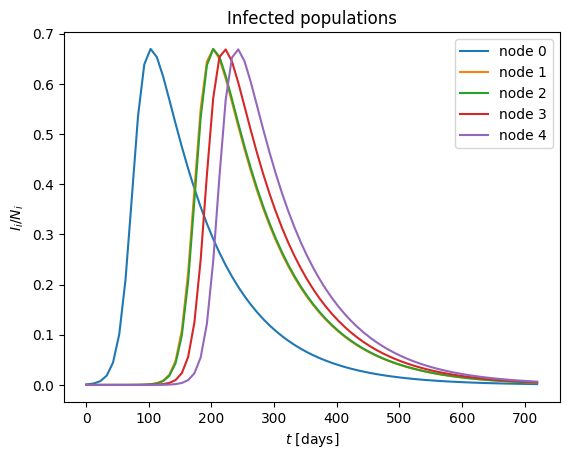

In [3]:
for (i, I_i) in enumerate(I):
    plt.plot(t, I_i / 1e5, label = f'node {i}')
    
plt.title('Infected populations')
plt.xlabel('$t$ [days]')
plt.ylabel('$I_i / N_i$')
plt.legend()

In [ ]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt
import networkx as nx

rng = np.random.default_rng(0)
n = 6

# Each node has a population of 100,000
populations = np.full(n, 1e5)

# Seed 0.1% infection in node 0; rest fully susceptible
S0 = np.array([0.999, 1.0, 1.0, 1.0, 1.0, 1.0]) * 1e5
I0 = np.array([0.001, 0.0, 0.0, 0.0, 0.0, 0.0]) * 1e5
R0 = np.zeros(n)
init_state = np.concatenate([S0, I0, R0])

# Asymmetric commuter matrix; zero diagonal; rows sum to 0.1
C = rng.uniform(0, 1, size=(n, n))

m = 
G = nx.barabasi_albert_graph(n, m)

# 2. Extract the connection (adjacency) matrix
# You can use the built-in NetworkX method
connection_matrix_sparse = nx.adjacency_matrix(G)

sim = Simulation(
    populations=populations,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=0.1,       
    recovery_rate=1000,        
    social_connectivity=10,
)
sim.solve_system(t_end=360*2) 
t, S, I, R = sim.get_results()

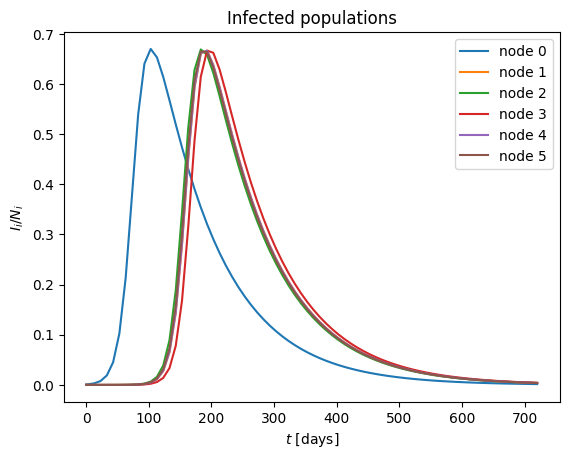

In [21]:
for (i, I_i) in enumerate(I):
    plt.plot(t, I_i / 1e5, label = f'node {i}')
    
plt.title('Infected populations')
plt.xlabel('$t$ [days]')
plt.ylabel('$I_i / N_i$')
plt.legend()

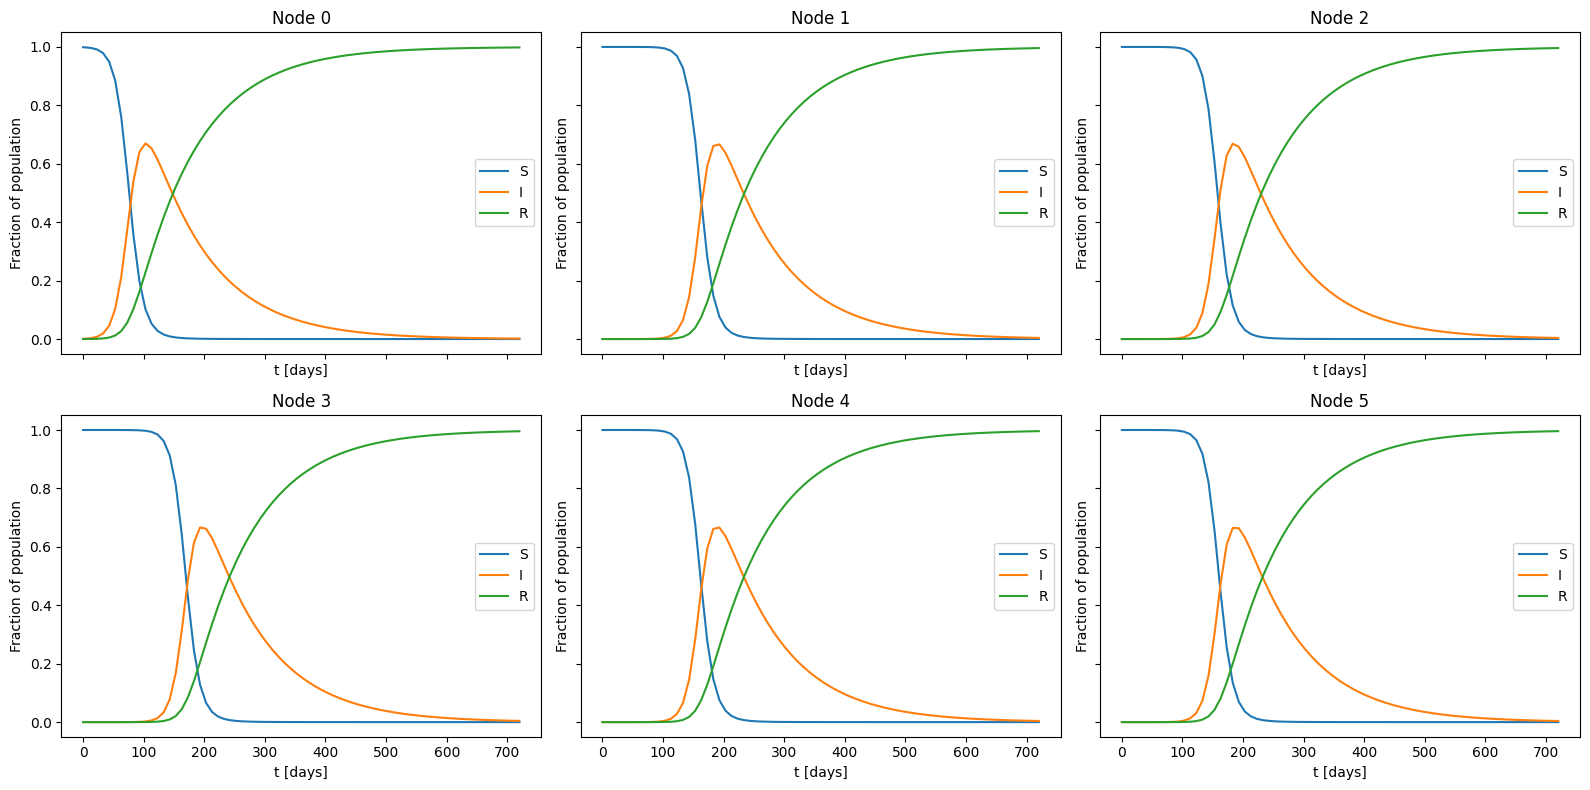

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat):
	ax.plot(t, S[i] / populations[i], label="S")
	ax.plot(t, I[i] / populations[i], label="I")
	ax.plot(t, R[i] / populations[i], label="R")
	ax.set_title(f"Node {i}")
	ax.set_xlabel("t [days]")
	ax.set_ylabel("Fraction of population")
	ax.legend()

plt.tight_layout()
plt.show()